In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

In [2]:
f_sig = "../coffea/AllInOne_2022/Resolution.coffea"

sig_histo = util.load(f_sig) [0]

Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.33333333 0.         0.         0.33333333
 0.         0.33333333 0.47140452 0.33333333 0.33333333 0.57735027
 0.47140452 0.         0.33333333 0.66666667 1.         0.94280904
 0.81649658 1.37436854 1.37436854 1.         0.57735027 0.66666667
 0.57735027 0.33333333 0.33333333 0.         0.33333333 0.33333333
 0.33333333 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.       

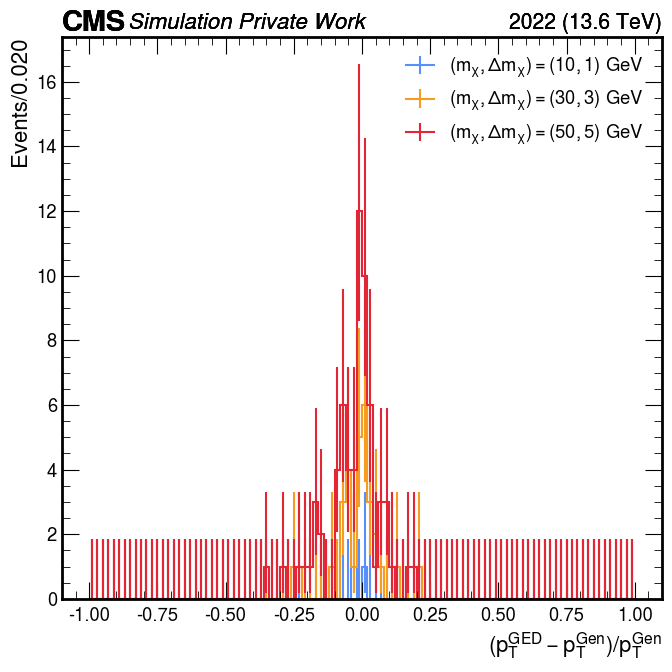

In [3]:
fig, ax = plt.subplots(figsize=(7,7))



# Plot settings
plot_dict = {
    'variable':'res_GED_gen',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': r'$(p_{T}^{\mathrm{GED}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$',
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}
#signal points
m1s=[10,30,50]
delta =0.1
ctau =10

results = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
    for m1 in m1s
]
counts, edges, yerror = zip(*results)

yerror = np.array(yerror)

edge = edges[0]
bins_x = (edge[:-1] + edge[1:])*(0.5)

avg = np.mean(counts, axis=0)

YERROR = (np.sqrt (np.sum( ( (yerror)**2), axis=0 )))/3
print (YERROR)

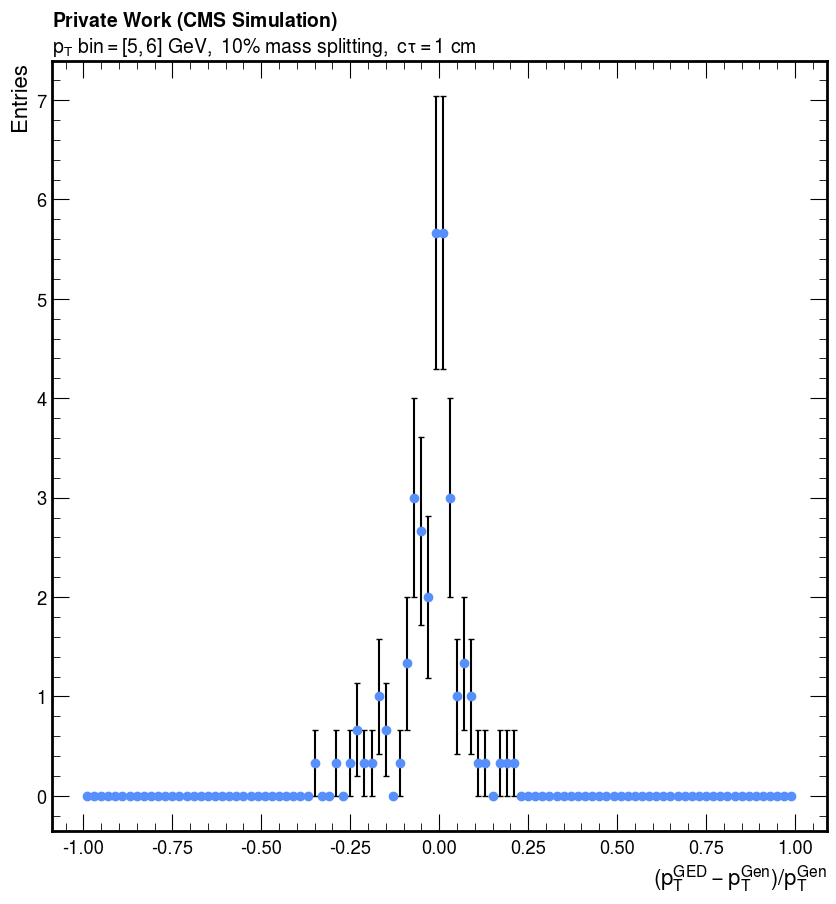

In [11]:
plt.errorbar(bins_x, avg, yerr=YERROR, fmt='o', capsize=2, ecolor='black')
plt.xlabel(r'$(p_{T}^{\mathrm{GED}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$')
plt.ylabel("Entries")

plt.title(
    r"$\bf{Private\ Work\ (CMS\ Simulation)}$"
    "\n"
    r"$\mathrm{p_{T}\ bin = [5,6]\ GeV,\ 10\%\ mass\ splitting,\ c\tau = 1\ cm}$",
    fontsize=14,
    loc="left",
)

plt.show()

Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.33333333 0.33333333 0.         0.
 0.33333333 0.33333333 0.47140452 0.47140452 0.47140452 0.33333333
 0.47140452 0.         0.57735027 0.57735027 1.15470054 0.74535599
 0.8819171  1.45296631 1.41421356 0.47140452 0.74535599 0.47140452
 0.57735027 0.33333333 0.         0.         0.47140452 0.33333333
 0.         0.         0.         0.         0.33333333 0.
 0.33333333 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.    

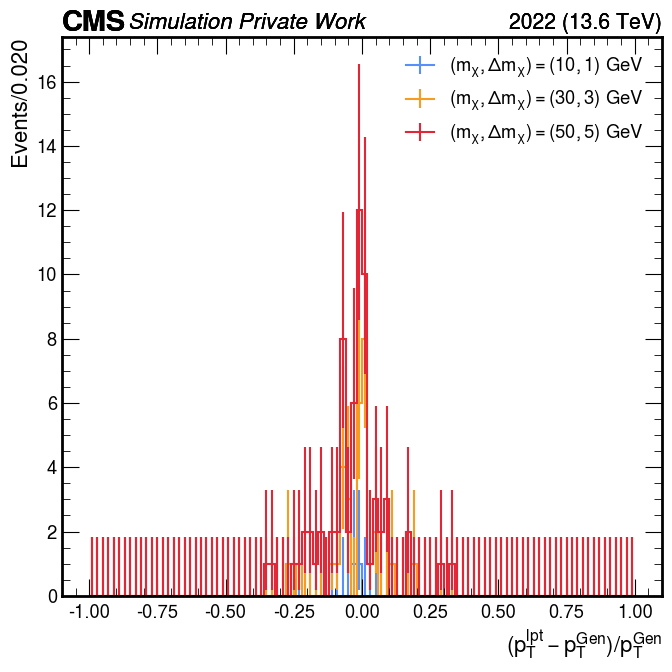

In [5]:
fig, ax = plt.subplots(figsize=(7,7))



# Plot settings
plot_dict = {
    'variable':'res_LPT_gen',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': r'$(p_{T}^{\mathrm{lpt}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$',
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}
#signal points
m1s=[10,30,50]
delta =0.1
ctau =10

results_lpt = [
    ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)
    
    for m1 in m1s
]
counts_lpt, edges_lpt, yerror_lpt = zip(*results_lpt)

yerror_lpt = np.array(yerror_lpt)

edge_lpt = edges_lpt[0]
bins_x_lpt = (edge_lpt[:-1] + edge_lpt[1:])*(0.5)

avg_lpt = np.mean(counts_lpt, axis=0)

YERROR_lpt = (np.sqrt (np.sum( ( (yerror_lpt)**2), axis=0 )))/3
print (YERROR_lpt)

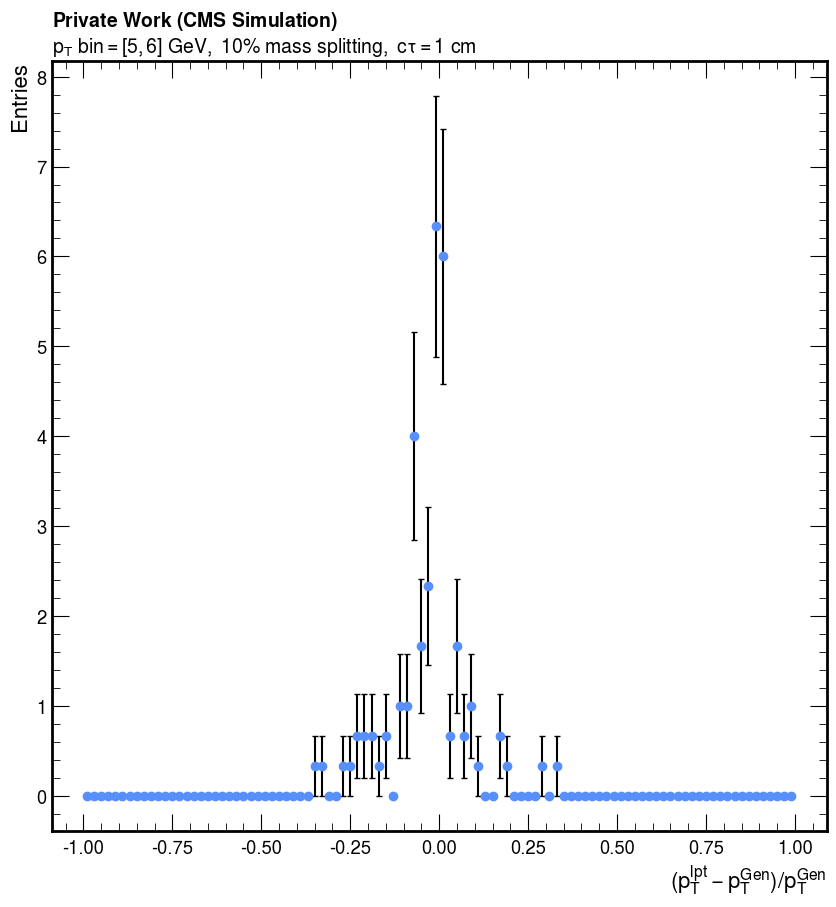

In [12]:
plt.errorbar(bins_x_lpt, avg_lpt, yerr=YERROR_lpt, fmt='o', capsize=2, ecolor='black')
plt.xlabel(r'$(p_{T}^{\mathrm{lpt}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$')
plt.ylabel("Entries")
plt.title(
    r"$\bf{Private\ Work\ (CMS\ Simulation)}$"
    "\n"
    r"$\mathrm{p_{T}\ bin = [5,6]\ GeV,\ 10\%\ mass\ splitting,\ c\tau = 1\ cm}$",
    fontsize=14,
    loc="left",
)
plt.show()